In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN184X 

##### (X=6 or 8)

In [20]:
import glob
import pandas as pd
import re

csv_folder = "/scratch/elena/9Li/results/run1846"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))


match = re.search(r'run(\d+)', csv_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Run number: 1846
Found 50 chunk files
Total clusters: 160085


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,8.041040e+09,6.109321e+05,77,0,500,"[103, 21, 36, 15, 83, 47, 47, 47, 111, 111, 11...","[98, 64, 46, 58, 28, 13, 13, 13, 97, 97, 97, 4...","[2, 14, 2, 17, 15, 14, 2, 16, 1, 8, 16, 9, 11,...","[0, 13, 0, 15, 5, 13, 0, 14, 6, 9, 14, 3, 11, ...","[8041039833.092616, 8041039832.952956, 8041039...","[123.0, 219.0, 123.0, 143.0, 234.0, 97.0, 127....",8.041040,0.610932
1,8.041410e+09,9.814304e+05,39,0,500,"[98, 98, 21, 93, 93, 93, 42, 99, 71, 71, 71, 9...","[100, 100, 64, 101, 101, 101, 80, 90, 103, 103...","[5, 3, 10, 3, 5, 4, 5, 17, 7, 9, 10, 8, 5, 16,...","[7, 18, 10, 18, 7, 1, 7, 15, 2, 3, 10, 9, 7, 1...","[8041410324.059747, 8041410326.036574, 8041410...","[67.0, 71.0, 54.0, 112.0, 96.0, 162.0, 128.0, ...",8.041410,0.981430
2,8.041415e+09,9.864002e+05,91,0,500,"[25, 23, 21, 42, 73, 47, 44, 107, 99, 99, 19, ...","[62, 47, 64, 80, 31, 13, 43, 44, 90, 90, 41, 6...","[0, 11, 3, 14, 11, 16, 10, 12, 6, 7, 14, 15, 8...","[17, 11, 18, 13, 11, 14, 10, 4, 8, 2, 13, 5, 9...","[8041415293.440109, 8041415301.218099, 8041415...","[153.0, 155.0, 109.0, 84.0, 176.0, 121.0, 155....",8.041415,0.986400
3,8.041850e+09,1.420935e+06,18,0,500,"[26, 16, 23, 1, 41, 24, 7, 12, 91, 108, 132, 1...","[60, 73, 47, 70, 49, 71, 34, 1, 94, 3, -1, -1,...","[18, 4, 10, 9, 13, 16, 4, 16, 9, 0, 17, 18, 13...","[16, 1, 10, 3, 12, 14, 1, 14, 3, 17, -2, -2, -...","[8041849833.819288, 8041849826.953714, 8041849...","[87.0, 45.0, 68.0, 139.0, 220.0, 151.0, 113.0,...",8.041850,1.420935
4,8.041970e+09,1.540646e+06,94,0,500,"[16, 16, 16, 16, 17, 21, 93, 93, 36, 15, 83, 7...","[73, 73, 73, 73, 29, 64, 101, 101, 46, 58, 28,...","[0, 15, 17, 16, 7, 5, 1, 17, 1, 15, 0, 5, 14, ...","[17, 5, 15, 14, 2, 7, 6, 15, 6, 5, 17, 7, 13, ...","[8041969548.267991, 8041969546.518477, 8041969...","[131.0, 131.0, 56.0, 137.0, 133.0, 197.0, 116....",8.041970,1.540646
...,...,...,...,...,...,...,...,...,...,...,...,...,...
160080,2.168147e+12,4.772774e+08,47,55,739,"[111, 98, 98, 36, 20, 99, 47, 47, 47, 47, 47, ...","[97, 100, 100, 46, 81, 90, 13, 13, 13, 13, 13,...","[13, 17, 12, 3, 17, 0, 1, 2, 4, 5, 6, 7, 9, 11...","[12, 15, 4, 18, 15, 17, 6, 0, 1, 7, 8, 2, 3, 1...","[2168147451765.116, 2168147451760.8503, 216814...","[157.0, 147.0, 85.0, 147.0, 130.0, 161.0, 146....",2168.147452,477.277395
160081,2.168148e+12,4.783110e+08,16,55,739,"[98, 42, 36, 11, 11, 11, 11, 3, 85, 45, 102, 1...","[100, 80, 46, 10, 10, 10, 10, 68, 93, 21, 22, ...","[15, 0, 14, 2, 9, 12, 14, 16, 13, 17, 4, 16, 1...","[5, 17, 13, 0, 3, 4, 13, 14, 12, 15, 1, 14, 16...","[2168148485342.3552, 2168148485343.5212, 21681...","[178.0, 134.0, 153.0, 125.0, 662.0, 387.0, 202...",2168.148485,478.310972
160082,2.168149e+12,4.789785e+08,52,55,739,"[98, 98, 98, 98, 42, 89, 89, 89, 32, 32, 16, 1...","[100, 100, 100, 100, 80, 89, 89, 89, 75, 75, 7...","[11, 13, 14, 9, 7, 6, 8, 11, 18, 7, 12, 17, 9,...","[11, 12, 13, 3, 2, 8, 9, 11, 16, 2, 4, 15, 3, ...","[2168149152809.4248, 2168149152809.061, 216814...","[160.0, 2475.0, 6292.0, 138.0, 130.0, 94.0, 15...",2168.149153,478.978452
160083,2.168149e+12,4.791636e+08,45,55,739,"[98, 98, 36, 32, 93, 35, 35, 35, 35, 35, 35, 3...","[100, 100, 46, 75, 101, 76, 76, 76, 76, 76, 76...","[8, 6, 10, 9, 1, 8, 9, 11, 12, 14, 15, 16, 1, ...","[9, 8, 10, 3, 6, 9, 3, 11, 4, 13, 5, 14, 6, 10...","[2168149337985.5942, 2168149337982.3071, 21681...","[289.0, 134.0, 354.0, 193.0, 165.0, 97.0, 308....",2168.149338,479.163620


In [21]:
activity_df = df.drop_duplicates(subset=['spill_id'])[['spill_id', 'nCLusters_in_spill']]
print(activity_df)

        spill_id  nCLusters_in_spill
0              0                 500
500            1                 482
982            2                 462
1444           3                 466
1910           4                 513
...          ...                 ...
156341        50                 751
157312        51                 521
157833        52                 503
158336        53                 477
158813        54                 533

[269 rows x 2 columns]


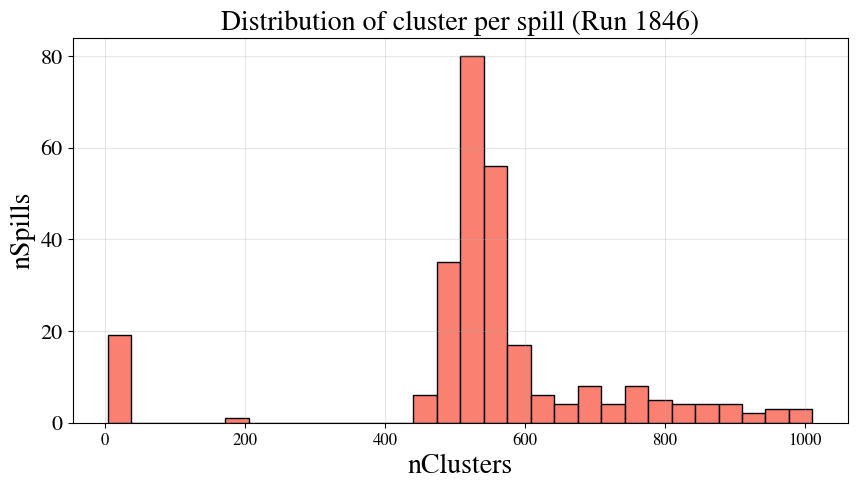

Total Clusters found in these spills: 146401
Average Clusters per 'Active' Spill: 544.24


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(activity_df['nCLusters_in_spill'], bins=30, color='salmon', edgecolor='black')
plt.title(f"Distribution of cluster per spill (Run {run_number})")
plt.xlabel("nClusters")
plt.ylabel("nSpills")
plt.grid(alpha=0.3)
plt.show()

print(f"Total Clusters found in these spills: {activity_df['nCLusters_in_spill'].sum()}")
print(f"Average Clusters per 'Active' Spill: {activity_df['nCLusters_in_spill'].mean():.2f}")

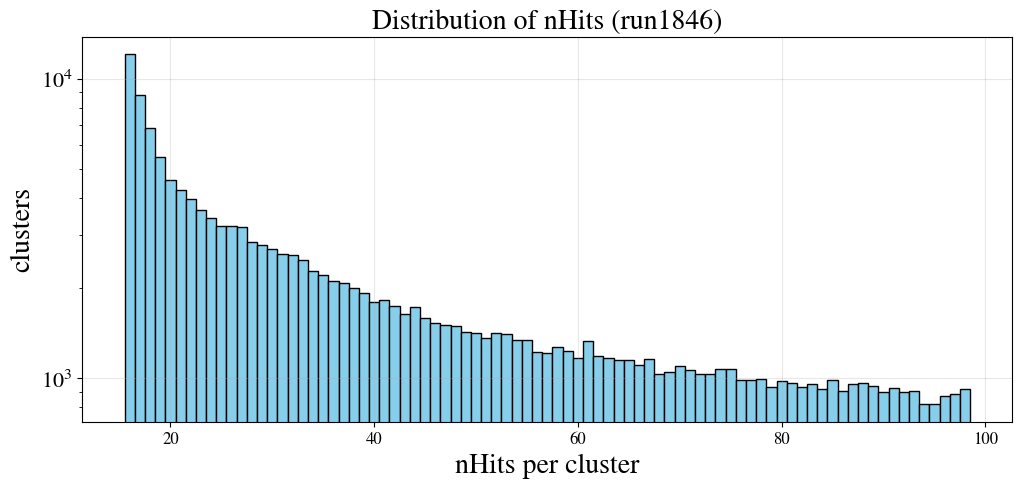

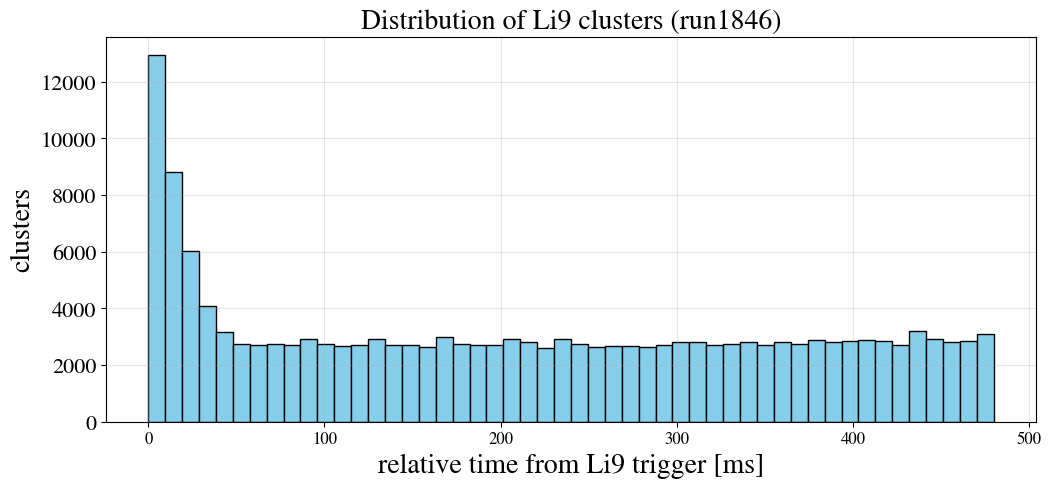

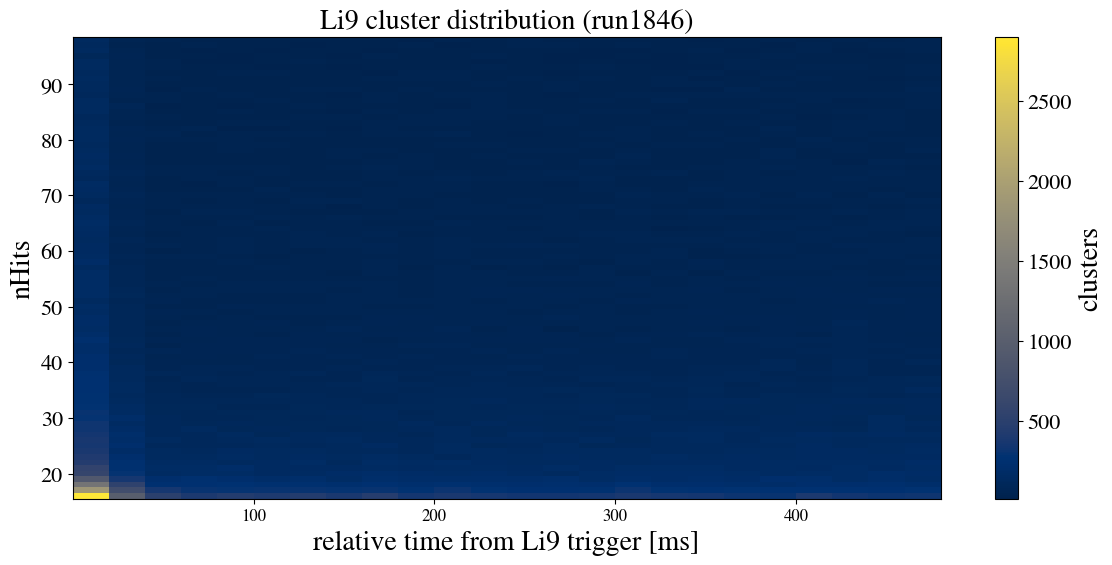

In [23]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title(f"Distribution of nHits (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title(f"Distribution of Li9 clusters (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title(f'Li9 cluster distribution (run{run_number})')
plt.show()